In [1]:
from pathlib import Path
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch

from ase.io import read
from anisoap.representations import EllipsoidalDensityProjection
from scipy.spatial.transform import Rotation
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

torch.set_default_dtype(torch.float64)

XYZ = Path("random_rotations.xyz").resolve()

STRIDE = 5
LMAX = 9
NMAX = 9
CUTOFF = 4.5
RADIAL_WIDTH = 1.0
NORMALIZE_POWER_SPECTRUM = False

frames = read(XYZ, ":")[::STRIDE]
for frame in frames:
    frame.info['energy'] = frame.get_potential_energy()

print("number of frames:", len(frames))
print("arrays:", sorted(frames[0].arrays))
print("info:", frames[0].info)

number of frames: 455
arrays: ['c_diameter[1]', 'c_diameter[2]', 'c_diameter[3]', 'numbers', 'positions', 'quaternions', 'torques']
info: {'separation_distance': np.float64(2.741019360474864), 'energy': np.float64(-0.3945812998088766)}


In [2]:
energies = np.array(
    [float(frame.info["energy"]) for frame in frames],
    dtype=float,
)

distances = np.array(
    [
        float(
            frame.info.get(
                "separation_distance",
                np.linalg.norm(frame.positions[1] - frame.positions[0]),
            )
        )
        for frame in frames
    ],
    dtype=float,
)


def normalized_quaternions(frame):
    q = np.asarray(frame.arrays["quaternions"], dtype=float)
    return q / np.linalg.norm(q, axis=1, keepdims=True)


def relative_rotation_angle(frame):
    q_wxyz = normalized_quaternions(frame)

    # SciPy expects xyzw.
    q0_xyzw = np.r_[q_wxyz[0, 1:], q_wxyz[0, 0]]
    q1_xyzw = np.r_[q_wxyz[1, 1:], q_wxyz[1, 0]]

    r0 = Rotation.from_quat(q0_xyzw)
    r1 = Rotation.from_quat(q1_xyzw)

    return (r1 * r0.inv()).magnitude()


relative_angles = np.array(
    [relative_rotation_angle(frame) for frame in frames]
)

print("energy range:", energies.min(), energies.max())
print("distance range:", distances.min(), distances.max())
print(
    "relative-angle range:",
    relative_angles.min(),
    relative_angles.max(),
)

energy range: -0.9870706275897596 -0.0597725093451465
distance range: 2.215312060715553 3.407480505596513
relative-angle range: 0.3036800334415652 3.1412955776560056


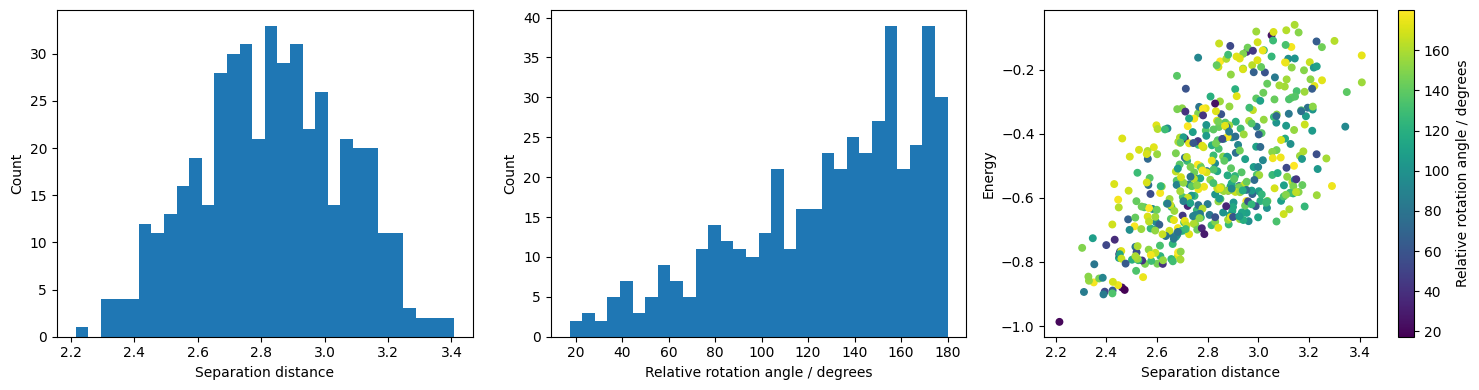

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(distances, bins=30)
axes[0].set_xlabel("Separation distance")
axes[0].set_ylabel("Count")

axes[1].hist(np.degrees(relative_angles), bins=30)
axes[1].set_xlabel("Relative rotation angle / degrees")
axes[1].set_ylabel("Count")

scatter = axes[2].scatter(
    distances,
    energies,
    c=np.degrees(relative_angles),
    s=22,
)
axes[2].set_xlabel("Separation distance")
axes[2].set_ylabel("Energy")
fig.colorbar(
    scatter,
    ax=axes[2],
    label="Relative rotation angle / degrees",
)

fig.tight_layout()
plt.show()

In [4]:
calculator = EllipsoidalDensityProjection(
    max_angular=LMAX,
    max_radial=NMAX,
    radial_basis_name="gto",
    cutoff_radius=CUTOFF,
    radial_gaussian_width=RADIAL_WIDTH,
    rotation_key="quaternions",
    rotation_type="quaternion",
    dtype=torch.float64,
)

calculator

EllipsoidalDensityProjection()

In [5]:
def power_spectrum(frame_list):
    with torch.no_grad():
        features = calculator.power_spectrum(
            frames=frame_list,
            mean_over_samples=True,
            normalize=NORMALIZE_POWER_SPECTRUM,
            show_progress=False,
        )

    return features.detach().cpu().numpy()


X = power_spectrum(frames)

print("feature matrix shape:", X.shape)
print("finite:", np.isfinite(X).all())
print(
    "feature norm range:",
    np.linalg.norm(X, axis=1).min(),
    np.linalg.norm(X, axis=1).max(),
)

feature matrix shape: (455, 1000)
finite: True
feature norm range: 3.5923005690409465e+20 1.0358913620805233e+24


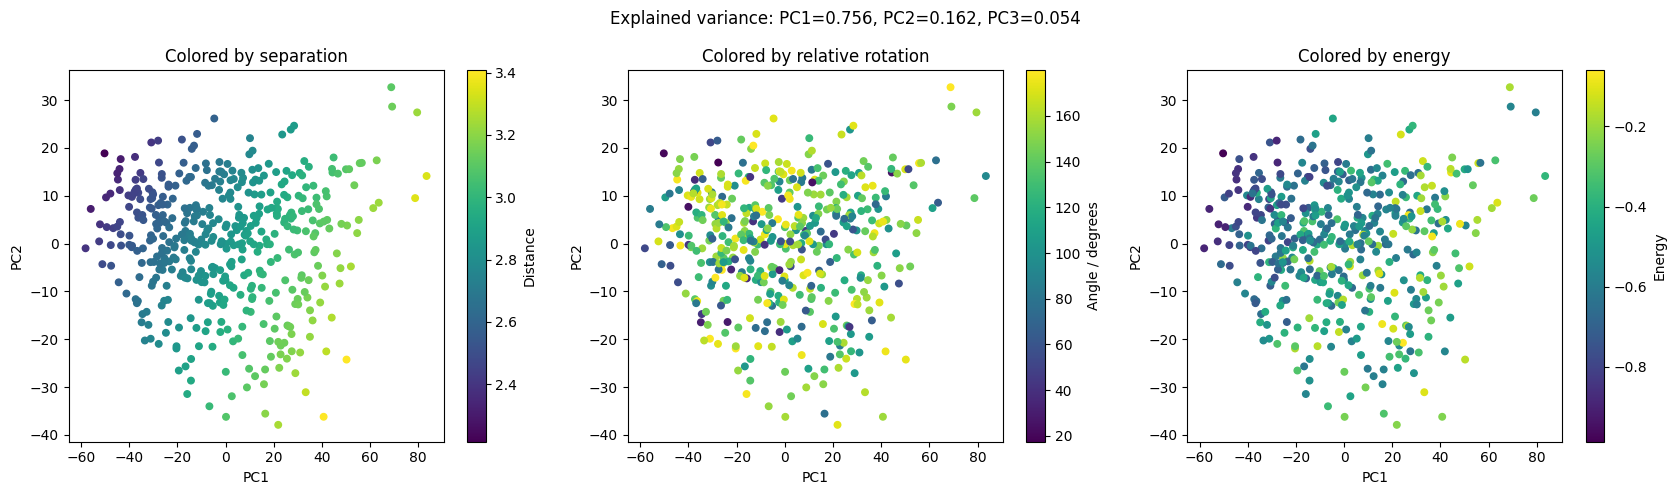

In [6]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=5)
Z = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sc0 = axes[0].scatter(
    Z[:, 0],
    Z[:, 1],
    c=distances,
    s=22,
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Colored by separation")
fig.colorbar(sc0, ax=axes[0], label="Distance")

sc1 = axes[1].scatter(
    Z[:, 0],
    Z[:, 1],
    c=np.degrees(relative_angles),
    s=22,
)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Colored by relative rotation")
fig.colorbar(sc1, ax=axes[1], label="Angle / degrees")

sc2 = axes[2].scatter(
    Z[:, 0],
    Z[:, 1],
    c=energies,
    s=22,
)
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
axes[2].set_title("Colored by energy")
fig.colorbar(sc2, ax=axes[2], label="Energy")

fig.suptitle(
    "Explained variance: "
    + ", ".join(
        f"PC{i + 1}={value:.3f}"
        for i, value in enumerate(pca.explained_variance_ratio_[:3])
    )
)
fig.tight_layout()
plt.show()

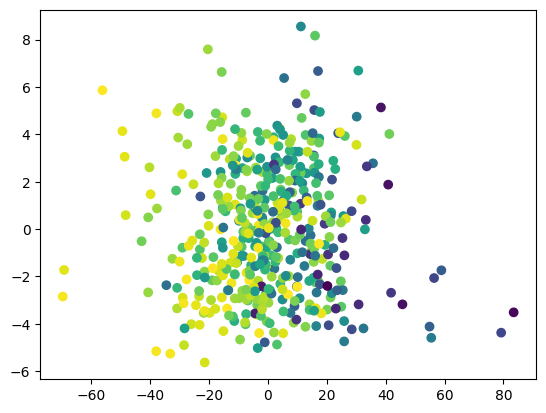

In [7]:
from skmatter.decomposition import PCovR
pcovr = PCovR(mixing=0.01, n_components=2)
T = pcovr.fit_transform(X_scaled, np.degrees(relative_angles))
plt.scatter(*T.T, c=np.degrees(relative_angles))

In [8]:
for component in range(5):
    print(
        f"PC{component + 1}: "
        f"corr(distance)={np.corrcoef(Z[:, component], distances)[0, 1]:+.3f}, "
        f"corr(angle)={np.corrcoef(Z[:, component], relative_angles)[0, 1]:+.3f}, "
        f"corr(energy)={np.corrcoef(Z[:, component], energies)[0, 1]:+.3f}"
    )

PC1: corr(distance)=+0.907, corr(angle)=+0.059, corr(energy)=+0.554
PC2: corr(distance)=-0.417, corr(angle)=+0.009, corr(energy)=-0.264
PC3: corr(distance)=-0.034, corr(angle)=-0.016, corr(energy)=-0.120
PC4: corr(distance)=-0.024, corr(angle)=+0.040, corr(energy)=-0.088
PC5: corr(distance)=-0.030, corr(angle)=+0.038, corr(energy)=-0.046


In [9]:
def set_particle_rotation(frame, particle, rotation_vector):
    result = frame.copy()

    q_wxyz = normalized_quaternions(result)
    q_xyzw = np.column_stack(
        [q_wxyz[:, 1], q_wxyz[:, 2], q_wxyz[:, 3], q_wxyz[:, 0]]
    )

    rotations = Rotation.from_quat(q_xyzw)
    delta = Rotation.from_rotvec(np.asarray(rotation_vector, dtype=float))

    updated = list(rotations)
    updated[particle] = delta * rotations[particle]

    updated_xyzw = Rotation.concatenate(updated).as_quat()

    updated_wxyz = np.column_stack(
        [
            updated_xyzw[:, 3],
            updated_xyzw[:, 0],
            updated_xyzw[:, 1],
            updated_xyzw[:, 2],
        ]
    )

    result.arrays["quaternions"] = updated_wxyz
    return result


def set_separation(frame, distance):
    result = frame.copy()

    direction = result.positions[1] - result.positions[0]
    direction = direction / np.linalg.norm(direction)

    center = 0.5 * (result.positions[0] + result.positions[1])

    result.positions[0] = center - 0.5 * distance * direction
    result.positions[1] = center + 0.5 * distance * direction

    result.info["separation_distance"] = float(distance)
    return result

In [10]:
median_distance = np.median(distances)
base_index = np.argmin(np.abs(distances - median_distance))
base = frames[base_index].copy()

print("base index:", base_index)
print("base distance:", distances[base_index])
print(
    "base relative angle / degrees:",
    np.degrees(relative_angles[base_index]),
)

base index: 177
base distance: 2.8395456862361494
base relative angle / degrees: 163.99325599227004


In [11]:
base_distance = np.linalg.norm(
    base.positions[1] - base.positions[0]
)

distance_offsets = np.linspace(-0.3, 0.3, 61)
distance_sweep = [
    set_separation(base, base_distance + offset)
    for offset in distance_offsets
]

angles = np.linspace(-np.pi, np.pi, 121)

rotate_particle_0 = [
    set_particle_rotation(base, 0, [0.0, 0.0, angle])
    for angle in angles
]

rotate_particle_1 = [
    set_particle_rotation(base, 1, [0.0, 0.0, angle])
    for angle in angles
]

global_rotation = [
    set_particle_rotation(
        set_particle_rotation(base, 0, [0.0, 0.0, angle]),
        1,
        [0.0, 0.0, angle],
    )
    for angle in angles
]

In [12]:
x0 = power_spectrum([base])[0]

X_distance = power_spectrum(distance_sweep)
X_rotate_0 = power_spectrum(rotate_particle_0)
X_rotate_1 = power_spectrum(rotate_particle_1)
X_global = power_spectrum(global_rotation)

distance_signal = np.linalg.norm(X_distance - x0, axis=1)
rotate_0_signal = np.linalg.norm(X_rotate_0 - x0, axis=1)
rotate_1_signal = np.linalg.norm(X_rotate_1 - x0, axis=1)
global_signal = np.linalg.norm(X_global - x0, axis=1)

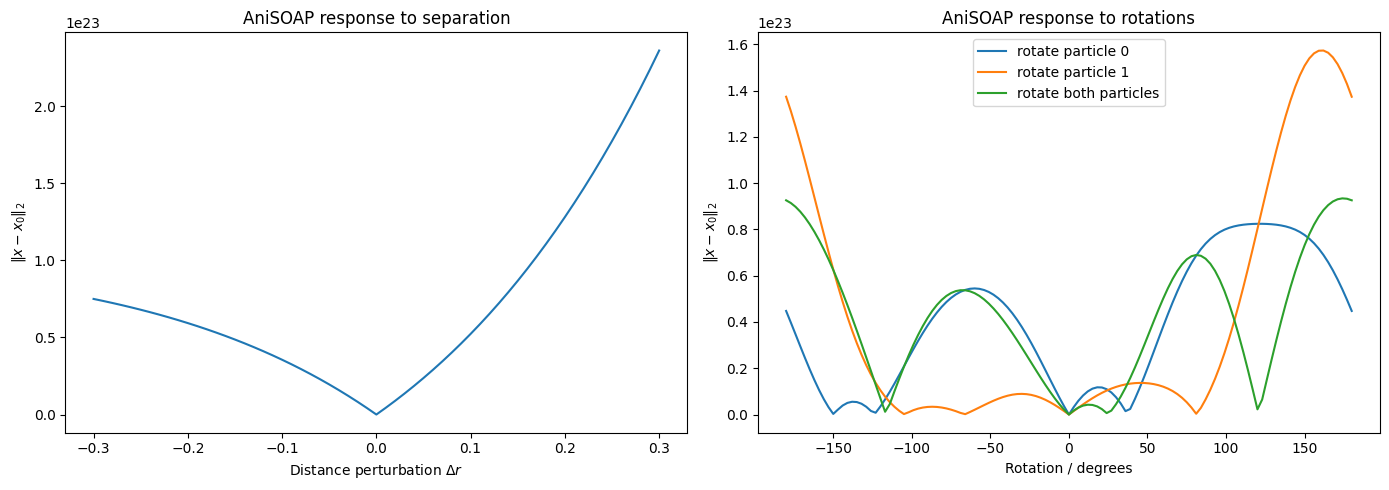

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    distance_offsets,
    distance_signal,
)
axes[0].set_xlabel(r"Distance perturbation $\Delta r$")
axes[0].set_ylabel(r"$\|x - x_0\|_2$")
axes[0].set_title("AniSOAP response to separation")

axes[1].plot(
    np.degrees(angles),
    rotate_0_signal,
    label="rotate particle 0",
)
axes[1].plot(
    np.degrees(angles),
    rotate_1_signal,
    label="rotate particle 1",
)
axes[1].plot(
    np.degrees(angles),
    global_signal,
    label="rotate both particles",
)
axes[1].set_xlabel("Rotation / degrees")
axes[1].set_ylabel(r"$\|x - x_0\|_2$")
axes[1].set_title("AniSOAP response to rotations")
axes[1].legend()

fig.tight_layout()
plt.show()

In [14]:
small_dr = 1e-3
small_dtheta = 1e-3

x_r_plus = power_spectrum(
    [set_separation(base, base_distance + small_dr)]
)[0]

x_r_minus = power_spectrum(
    [set_separation(base, base_distance - small_dr)]
)[0]

dx_dr = (x_r_plus - x_r_minus) / (2 * small_dr)

x_q0_plus = power_spectrum(
    [set_particle_rotation(base, 0, [0, 0, small_dtheta])]
)[0]

x_q0_minus = power_spectrum(
    [set_particle_rotation(base, 0, [0, 0, -small_dtheta])]
)[0]

dx_dtheta_0 = (
    x_q0_plus - x_q0_minus
) / (2 * small_dtheta)

x_q1_plus = power_spectrum(
    [set_particle_rotation(base, 1, [0, 0, small_dtheta])]
)[0]

x_q1_minus = power_spectrum(
    [set_particle_rotation(base, 1, [0, 0, -small_dtheta])]
)[0]

dx_dtheta_1 = (
    x_q1_plus - x_q1_minus
) / (2 * small_dtheta)

print("||dx/dr||:", np.linalg.norm(dx_dr))
print("||dx/dtheta particle 0||:", np.linalg.norm(dx_dtheta_0))
print("||dx/dtheta particle 1||:", np.linalg.norm(dx_dtheta_1))

print()
print(
    "particle 0 rotation / radial sensitivity:",
    np.linalg.norm(dx_dtheta_0) / np.linalg.norm(dx_dr),
)
print(
    "particle 1 rotation / radial sensitivity:",
    np.linalg.norm(dx_dtheta_1) / np.linalg.norm(dx_dr),
)

||dx/dr||: 4.293303491718386e+23
||dx/dtheta particle 0||: 6.370005072783684e+22
||dx/dtheta particle 1||: 2.78959252228545e+22

particle 0 rotation / radial sensitivity: 0.14837071465064544
particle 1 rotation / radial sensitivity: 0.06497543273301001


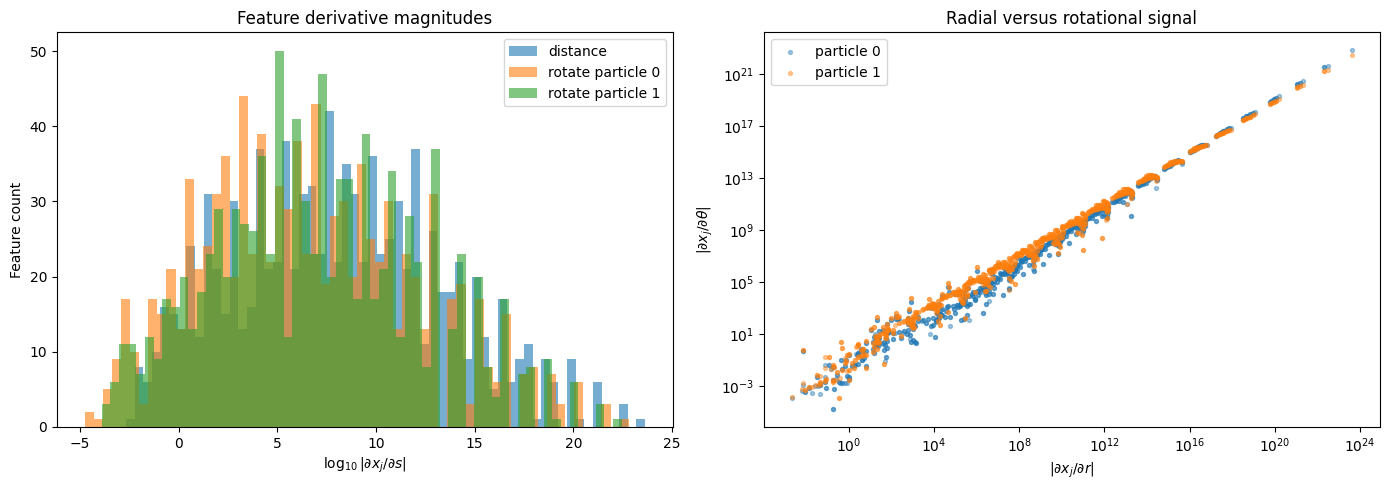

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    np.log10(np.abs(dx_dr) + 1e-30),
    bins=60,
    alpha=0.6,
    label="distance",
)
axes[0].hist(
    np.log10(np.abs(dx_dtheta_0) + 1e-30),
    bins=60,
    alpha=0.6,
    label="rotate particle 0",
)
axes[0].hist(
    np.log10(np.abs(dx_dtheta_1) + 1e-30),
    bins=60,
    alpha=0.6,
    label="rotate particle 1",
)
axes[0].set_xlabel(r"$\log_{10} |\partial x_j / \partial s|$")
axes[0].set_ylabel("Feature count")
axes[0].set_title("Feature derivative magnitudes")
axes[0].legend()

axes[1].scatter(
    np.abs(dx_dr),
    np.abs(dx_dtheta_0),
    s=8,
    alpha=0.4,
    label="particle 0",
)
axes[1].scatter(
    np.abs(dx_dr),
    np.abs(dx_dtheta_1),
    s=8,
    alpha=0.4,
    label="particle 1",
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$|\partial x_j / \partial r|$")
axes[1].set_ylabel(r"$|\partial x_j / \partial \theta|$")
axes[1].set_title("Radial versus rotational signal")
axes[1].legend()

fig.tight_layout()
plt.show()

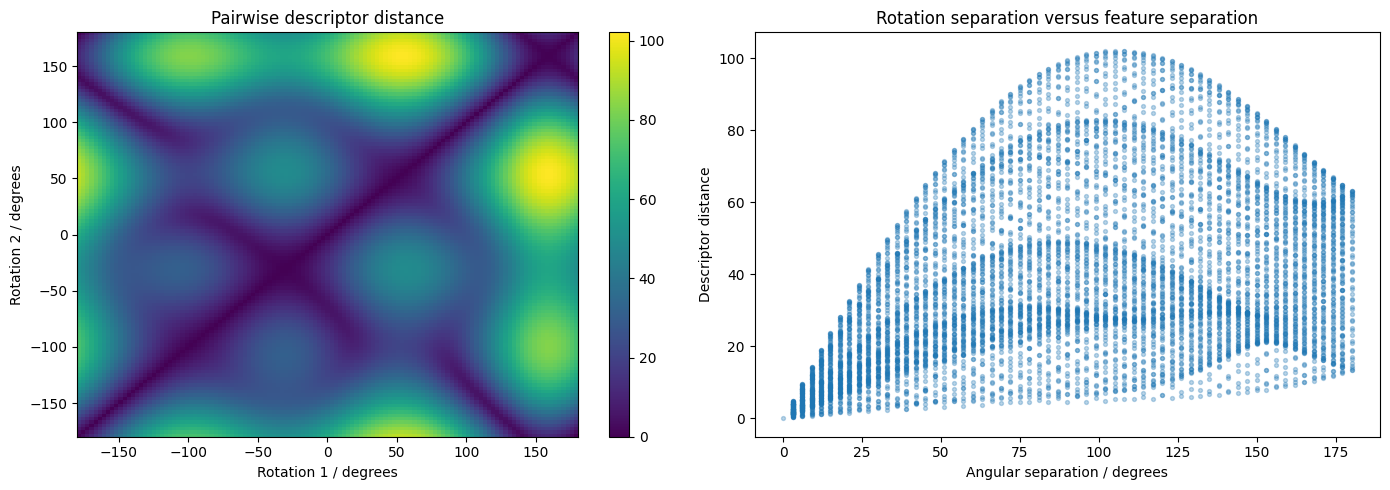

In [16]:
X_rot_scaled = StandardScaler().fit_transform(X_rotate_1)

pairwise_feature_distance = np.linalg.norm(
    X_rot_scaled[:, None, :] - X_rot_scaled[None, :, :],
    axis=2,
)

angle_difference = np.abs(
    angles[:, None] - angles[None, :]
)

# Wrap angle differences into [0, pi].
angle_difference = np.minimum(
    angle_difference,
    2 * np.pi - angle_difference,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

image = axes[0].imshow(
    pairwise_feature_distance,
    origin="lower",
    aspect="auto",
    extent=[
        np.degrees(angles[0]),
        np.degrees(angles[-1]),
        np.degrees(angles[0]),
        np.degrees(angles[-1]),
    ],
)
axes[0].set_xlabel("Rotation 1 / degrees")
axes[0].set_ylabel("Rotation 2 / degrees")
axes[0].set_title("Pairwise descriptor distance")
fig.colorbar(image, ax=axes[0])

iu = np.triu_indices(len(angles), k=1)

axes[1].scatter(
    np.degrees(angle_difference[iu]),
    pairwise_feature_distance[iu],
    s=8,
    alpha=0.3,
)
axes[1].set_xlabel("Angular separation / degrees")
axes[1].set_ylabel("Descriptor distance")
axes[1].set_title("Rotation separation versus feature separation")

fig.tight_layout()
plt.show()

In [17]:
minimum_angle_difference = np.deg2rad(20)

mask = angle_difference[iu] > minimum_angle_difference

candidate_distances = pairwise_feature_distance[iu][mask]
candidate_i = iu[0][mask]
candidate_j = iu[1][mask]

order = np.argsort(candidate_distances)

print(
    "Large rotation differences with the smallest descriptor differences:"
)

for index in order[:15]:
    i = candidate_i[index]
    j = candidate_j[index]

    print(
        f"{np.degrees(angles[i]):8.2f}° vs "
        f"{np.degrees(angles[j]):8.2f}° | "
        f"Δangle={np.degrees(angle_difference[i, j]):7.2f}° | "
        f"Δfeature={pairwise_feature_distance[i, j]:.6e}"
    )

Large rotation differences with the smallest descriptor differences:
  150.00° vs   171.00° | Δangle=  21.00° | Δfeature=1.557692e+00
  147.00° vs   174.00° | Δangle=  27.00° | Δfeature=1.917298e+00
  -42.00° vs   -21.00° | Δangle=  21.00° | Δfeature=2.035124e+00
  144.00° vs   177.00° | Δangle=  33.00° | Δfeature=2.234844e+00
  147.00° vs   171.00° | Δangle=  24.00° | Δfeature=2.300670e+00
  -42.00° vs   -18.00° | Δangle=  24.00° | Δfeature=2.514134e+00
 -180.00° vs   141.00° | Δangle=  39.00° | Δfeature=2.521856e+00
  141.00° vs   180.00° | Δangle=  39.00° | Δfeature=2.521856e+00
  -45.00° vs   -21.00° | Δangle=  24.00° | Δfeature=2.566136e+00
  -45.00° vs   -18.00° | Δangle=  27.00° | Δfeature=2.574346e+00
  -39.00° vs   -18.00° | Δangle=  21.00° | Δfeature=2.723224e+00
 -177.00° vs   138.00° | Δangle=  45.00° | Δfeature=2.797024e+00
  -45.00° vs   -24.00° | Δangle=  21.00° | Δfeature=2.808802e+00
  144.00° vs   174.00° | Δangle=  30.00° | Δfeature=2.906534e+00
 -174.00° vs   135.00

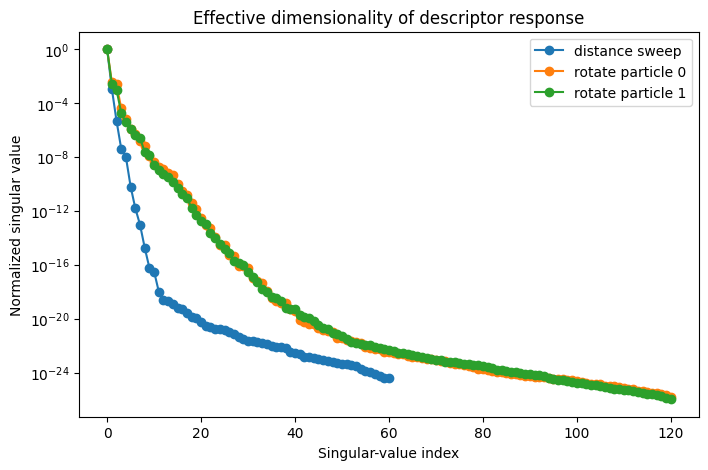

In [18]:
D_distance = X_distance - X_distance.mean(axis=0)
D_rotate_0 = X_rotate_0 - X_rotate_0.mean(axis=0)
D_rotate_1 = X_rotate_1 - X_rotate_1.mean(axis=0)

s_distance = np.linalg.svd(D_distance, compute_uv=False)
s_rotate_0 = np.linalg.svd(D_rotate_0, compute_uv=False)
s_rotate_1 = np.linalg.svd(D_rotate_1, compute_uv=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(
    s_distance / s_distance[0],
    marker="o",
    label="distance sweep",
)
ax.semilogy(
    s_rotate_0 / s_rotate_0[0],
    marker="o",
    label="rotate particle 0",
)
ax.semilogy(
    s_rotate_1 / s_rotate_1[0],
    marker="o",
    label="rotate particle 1",
)

ax.set_xlabel("Singular-value index")
ax.set_ylabel("Normalized singular value")
ax.set_title("Effective dimensionality of descriptor response")
ax.legend()

plt.show()